In [1]:
if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  readxl,
  tidyverse,
  lubridate,
  fixest,
  scales
)

rm(list = ls())
options(scipen = 999)

Cargando paquete requerido: pacman



In [2]:
df <- tribble(
~concesionario, ~anio, ~mes, ~tkm_acum,

# ================= FXE =================
"FXE",2020,1,3.90269,"FXE",2020,2,8.00268,"FXE",2020,3,12.31120,"FXE",2020,4,16.12207,
"FXE",2020,5,20.19277,"FXE",2020,6,24.27409,"FXE",2020,7,28.53284,"FXE",2020,8,32.86181,
"FXE",2020,9,36.59874,"FXE",2020,10,40.62200,"FXE",2020,11,44.93460,"FXE",2020,12,49.09206,

"FXE",2021,1,4.34732,"FXE",2021,2,8.12117,"FXE",2021,3,12.85792,"FXE",2021,4,17.33419,
"FXE",2021,5,22.27492,"FXE",2021,6,26.73943,"FXE",2021,7,31.57316,"FXE",2021,8,36.41586,
"FXE",2021,9,40.91495,"FXE",2021,10,45.47087,"FXE",2021,11,49.90088,"FXE",2021,12,54.38701,

"FXE",2022,1,4.16529,"FXE",2022,2,7.84538,"FXE",2022,3,12.05416,"FXE",2022,4,16.12118,
"FXE",2022,5,20.32706,"FXE",2022,6,24.34130,"FXE",2022,7,28.30592,"FXE",2022,8,32.21994,
"FXE",2022,9,36.26371,"FXE",2022,10,40.01412,"FXE",2022,11,43.88567,"FXE",2022,12,47.72600,

"FXE",2023,1,4.47504,"FXE",2023,2,8.66487,"FXE",2023,3,13.25997,"FXE",2023,4,17.46394,
"FXE",2023,5,21.82866,"FXE",2023,6,26.27251,"FXE",2023,7,30.13466,"FXE",2023,8,34.59066,
"FXE",2023,9,38.75882,"FXE",2023,10,43.04794,"FXE",2023,11,47.17276,"FXE",2023,12,50.78045,

# ================= KCSM =================
"KCSM",2020,1,2.55795,"KCSM",2020,2,5.16933,"KCSM",2020,3,7.88929,"KCSM",2020,4,9.98165,
"KCSM",2020,5,11.93734,"KCSM",2020,6,14.11627,"KCSM",2020,7,16.54512,"KCSM",2020,8,19.03246,
"KCSM",2020,9,21.78292,"KCSM",2020,10,24.49632,"KCSM",2020,11,26.97281,"KCSM",2020,12,29.59876,

"KCSM",2021,1,2.71973,"KCSM",2021,2,5.00908,"KCSM",2021,3,7.75502,"KCSM",2021,4,10.44243,
"KCSM",2021,5,13.36542,"KCSM",2021,6,15.99522,"KCSM",2021,7,18.57060,"KCSM",2021,8,20.86512,
"KCSM",2021,9,23.20130,"KCSM",2021,10,25.45351,"KCSM",2021,11,27.94080,"KCSM",2021,12,30.39573,

"KCSM",2022,1,2.51678,"KCSM",2022,2,4.89169,"KCSM",2022,3,7.55251,"KCSM",2022,4,10.12823,
"KCSM",2022,5,12.80935,"KCSM",2022,6,15.55510,"KCSM",2022,7,18.13048,"KCSM",2022,8,20.79373,
"KCSM",2022,9,23.38974,"KCSM",2022,10,26.02244,"KCSM",2022,11,28.75227,"KCSM",2022,12,31.35891,

"KCSM",2023,1,2.86291,"KCSM",2023,2,5.45073,"KCSM",2023,3,8.30659,"KCSM",2023,4,11.01583,
"KCSM",2023,5,13.71285,"KCSM",2023,6,16.31929,"KCSM",2023,7,19.00446,"KCSM",2023,8,21.58328,
"KCSM",2023,9,24.30670,"KCSM",2023,10,27.19512,"KCSM",2023,11,29.96069,"KCSM",2023,12,32.82898,

# ================= FSRR =================
"FSRR",2020,1,0.61368,"FSRR",2020,2,1.19034,"FSRR",2020,3,1.74037,"FSRR",2020,4,2.31714,
"FSRR",2020,5,2.80758,"FSRR",2020,6,3.31297,"FSRR",2020,7,3.92949,"FSRR",2020,8,4.50899,
"FSRR",2020,9,5.02532,"FSRR",2020,10,5.56812,"FSRR",2020,11,6.08320,"FSRR",2020,12,6.60091,

"FSRR",2021,1,0.54414,"FSRR",2021,2,1.07151,"FSRR",2021,3,1.67627,"FSRR",2021,4,2.28883,
"FSRR",2021,5,2.87926,"FSRR",2021,6,3.46094,"FSRR",2021,7,4.09596,"FSRR",2021,8,4.71159,
"FSRR",2021,9,5.28595,"FSRR",2021,10,5.88430,"FSRR",2021,11,6.49133,"FSRR",2021,12,7.05584,

"FSRR",2022,1,0.58490,"FSRR",2022,2,1.12553,"FSRR",2022,3,1.74667,"FSRR",2022,4,2.33660,
"FSRR",2022,5,2.82052,"FSRR",2022,6,3.44271,"FSRR",2022,7,4.05203,"FSRR",2022,8,4.73316,
"FSRR",2022,9,5.38409,"FSRR",2022,10,6.07176,"FSRR",2022,11,6.73834,"FSRR",2022,12,7.45241,

"FSRR",2023,1,0.73014,"FSRR",2023,2,1.38036,"FSRR",2023,3,2.06371,"FSRR",2023,4,2.72415,
"FSRR",2023,5,3.41524,"FSRR",2023,6,4.05658,"FSRR",2023,7,4.68560,"FSRR",2023,8,5.43282,
"FSRR",2023,9,6.13309,"FSRR",2023,10,6.84279,"FSRR",2023,11,7.47605,"FSRR",2023,12,8.11886
)

In [3]:
tabla1 <- df %>%
  filter(mes == 12, anio %in% c(2020, 2023)) %>%
  
  select(concesionario, anio, tkm_acum) %>%
  
  pivot_wider(
    names_from = anio,
    values_from = tkm_acum,
    names_prefix = "tkm_"
  ) %>%
  
  mutate(
    # Participación 2023
    participacion = tkm_2023 / sum(tkm_2023),
    
    # TMAC 2020–2023
    tmac = (tkm_2023 / tkm_2020)^(1/3) - 1
  )

tabla1_fmt <- tabla1 %>%
  mutate(
    ton_km = sprintf("%.3f", tkm_2023),
    participacion = sprintf("%.1f%%", participacion * 100),
    tmac = sprintf("%+.1f%%", tmac * 100)
  ) %>%
  select(concesionario, ton_km, participacion, tmac)

tabla1_fmt

concesionario,ton_km,participacion,tmac
<chr>,<chr>,<chr>,<chr>
FXE,50.780,55.4%,+1.1%
KCSM,32.829,35.8%,+3.5%
FSRR,8.119,8.9%,+7.1%


In [4]:
df_model <- df %>%
  mutate(
    fecha = as.Date(paste(anio, mes, "01", sep = "-"))
  ) %>%
  arrange(concesionario, fecha) %>%
  group_by(concesionario, anio) %>%
  mutate(
    tkm_mes = tkm_acum - lag(tkm_acum),
    tkm_mes = if_else(mes == 1, tkm_acum, tkm_mes)
  ) %>%
  ungroup() %>%
  mutate(
    ln_tkm = log(tkm_mes)
  )

In [5]:
# M0
m0 <- feols(ln_tkm ~ 1, data = df_model)

# M1: FE operador
m1 <- feols(ln_tkm ~ 1 | concesionario, data = df_model)

# M2: FE tiempo
m2 <- feols(ln_tkm ~ 1 | fecha, data = df_model)

# M3: FE dobles
m3 <- feols(ln_tkm ~ 1 | concesionario + fecha, data = df_model)

In [6]:
r2_m0 <- as.numeric(fitstat(m0, "r2"))
r2_m1 <- as.numeric(fitstat(m1, "r2"))
r2_m2 <- as.numeric(fitstat(m2, "r2"))
r2_m3 <- as.numeric(fitstat(m3, "r2"))

# Reemplazar NaN por 0
r2_m0 <- ifelse(is.na(r2_m0), 0, r2_m0)
r2_m1 <- ifelse(is.na(r2_m1), 0, r2_m1)
r2_m2 <- ifelse(is.na(r2_m2), 0, r2_m2)
r2_m3 <- ifelse(is.na(r2_m3), 0, r2_m3)

residuo <- 1 - r2_m3
N <- nrow(df_model)
# Guardar resultados del panel mensual para tabla comparativa (Cell 14)
res_mensual <- tibble(
  fe_operador = r2_m1,
  fe_tiempo   = r2_m2,
  fe_doble    = r2_m3,
  residuo     = 1 - r2_m3
)


In [7]:
tabla2 <- tibble(
  Modelo = c(
    "[M0] Sin efectos fijos",
    "[M1] FE Operador",
    "[M2] FE Tiempo",
    "[M3] FE Dobles (op+tiempo)",
    "Residuo idiosincrático",
    "Observaciones (N)"
  ),
  
  R2 = c(
    sprintf("%.4f", r2_m0),
    sprintf("%.4f", r2_m1),
    sprintf("%.4f", r2_m2),
    sprintf("%.4f", r2_m3),
    sprintf("%.4f", residuo),
    as.character(N)
  ),
  
  Interpretacion = c(
    "Referencia (media del sistema)",
    paste0(round(r2_m1*100,1), "% de la varianza es estructural"),
    paste0(round(r2_m2*100,1), "% responde a shocks comunes"),
    "Explicación conjunta casi total",
    "Variación no explicada por ningún FE",
    "3 operadores × 48 meses"
  )
)

tabla2

Modelo,R2,Interpretacion
<chr>,<chr>,<chr>
[M0] Sin efectos fijos,0.0000,Referencia (media del sistema)
[M1] FE Operador,0.9885,98.8% de la varianza es estructural
[M2] FE Tiempo,0.0056,0.6% responde a shocks comunes
[M3] FE Dobles (op+tiempo),0.9941,Explicación conjunta casi total
Residuo idiosincrático,0.0059,Variación no explicada por ningún FE
Observaciones (N),144,3 operadores × 48 meses


In [8]:
resultado_central <- paste0(
  "Resultado central — Panel mensual (N=", N, ", 2020m1–2023m12):\n",
  "FE Operador: R²=", sprintf("%.4f", r2_m1),
  " | FE Tiempo: R²=", sprintf("%.4f", r2_m2),
  " | FE Dobles: R²=", sprintf("%.4f", r2_m3),
  " | Residuo: ", sprintf("%.4f", residuo)
)

cat(resultado_central)

Resultado central — Panel mensual (N=144, 2020m1–2023m12):
FE Operador: R²=0.9885 | FE Tiempo: R²=0.0056 | FE Dobles: R²=0.9941 | Residuo: 0.0059

In [9]:
# =========================
# 1. COMPONENTES
# =========================
descomp <- tibble(
  componente = c(
    "Heterogeneidad de operador",
    "Residuo idiosincrático",
    "Variación temporal",
    "Interacción op × tiempo"
  ),
  
  valor = c(
    r2_m1,
    1 - r2_m3,
    r2_m2,
    r2_m3 - r2_m1 - r2_m2
  )
)

# Orden como en la figura
descomp <- descomp %>%
  mutate(componente = factor(
    componente,
    levels = rev(componente)
  ))

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_col()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text()`)."


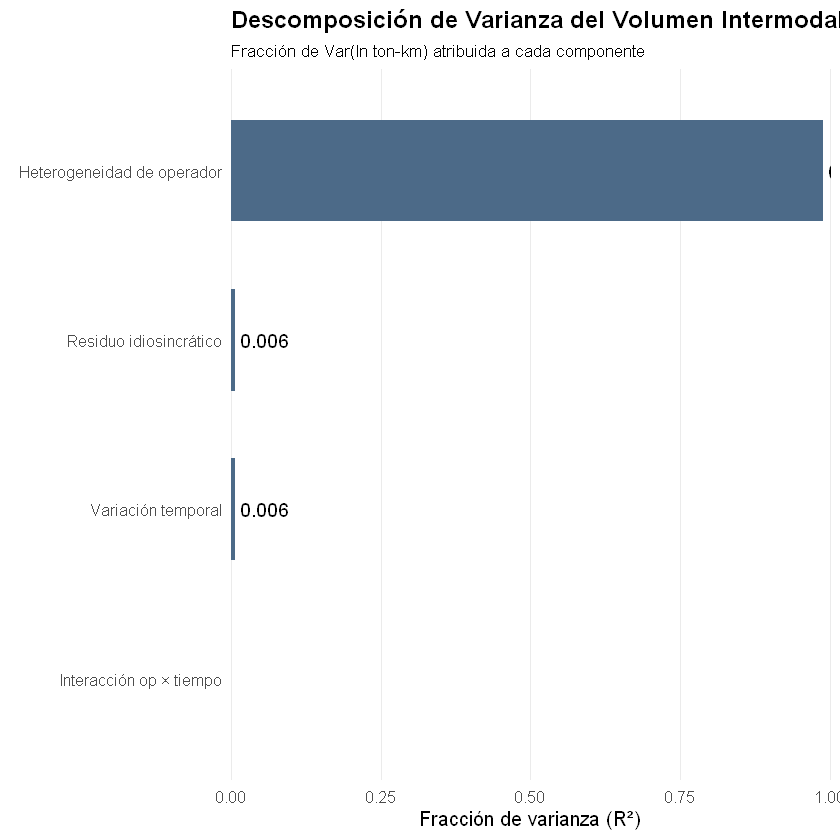

In [10]:
ggplot(descomp, aes(x = valor, y = componente)) +
  
  geom_col(fill = "#4C6A88", width = 0.6) +
  
  geom_text(
    aes(label = sprintf("%.3f", valor)),
    hjust = -0.1,
    size = 4
  ) +
  
  scale_x_continuous(
    limits = c(0, 1),
    expand = c(0, 0)
  ) +
  
  labs(
    title = "Descomposición de Varianza del Volumen Intermodal",
    subtitle = "Fracción de Var(ln ton-km) atribuida a cada componente",
    x = "Fracción de varianza (R²)",
    y = NULL
  ) +
  
  theme_minimal(base_size = 12) +
  
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    plot.subtitle = element_text(size = 10)
  )

In [11]:
df_anual <- tribble(
~concesionario, ~anio, ~tkm_mill, ~ton_mill,

# FXE
"FXE",2017,45.66399,58.33,
"FXE",2018,48.39755,61.79,
"FXE",2019,50.09491,59.90,
"FXE",2020,49.09206,58.04,
"FXE",2021,54.38701,64.24,
"FXE",2022,47.72600,61.35,
"FXE",2023,50.78045,61.66,

# KCSM
"KCSM",2017,30.40986,43.05,
"KCSM",2018,29.93954,43.61,
"KCSM",2019,30.16023,44.24,
"KCSM",2020,29.59877,44.00,
"KCSM",2021,30.39572,46.03,
"KCSM",2022,31.35891,47.59,
"KCSM",2023,32.82897,50.41,

# FSRR
"FSRR",2017,8.81873,18.88,
"FSRR",2018,8.06172,15.93,
"FSRR",2019,7.25340,14.98,
"FSRR",2020,6.60090,13.35,
"FSRR",2021,7.05584,14.28,
"FSRR",2022,7.45239,15.01,
"FSRR",2023,8.11885,15.73
) %>%
  mutate(
    ln_tkm = log(tkm_mill)
  )

  df_anual

concesionario,anio,tkm_mill,ton_mill,ln_tkm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
FXE,2017,45.66399,58.33,3.821310
FXE,2018,48.39755,61.79,3.879449
FXE,2019,50.09491,59.90,3.913919
FXE,2020,49.09206,58.04,3.893697
FXE,2021,54.38701,64.24,3.996125
FXE,2022,47.72600,61.35,3.865476
FXE,2023,50.78045,61.66,3.927511
KCSM,2017,30.40986,43.05,3.414767
KCSM,2018,29.93954,43.61,3.399180


In [12]:
get_r2 <- function(data, y, id, time) {
  
  get_val <- function(m) {
    val <- as.numeric(fitstat(m, "r2"))
    ifelse(is.na(val) | is.nan(val), 0, val)
  }
  
  m1 <- feols(as.formula(paste0(y, " ~ 1 | ", id)), data = data)
  m2 <- feols(as.formula(paste0(y, " ~ 1 | ", time)), data = data)
  m3 <- feols(as.formula(paste0(y, " ~ 1 | ", id, " + ", time)), data = data)
  
  r2_m1 <- get_val(m1)
  r2_m2 <- get_val(m2)
  r2_m3 <- get_val(m3)
  
  tibble(
    fe_operador = r2_m1,
    fe_tiempo   = r2_m2,
    fe_doble    = r2_m3,
    residuo     = 1 - r2_m3
  )
}

In [13]:
# Anual completo
res_anual <- get_r2(df_anual, "ln_tkm", "concesionario", "anio")

# Pre-COVID
res_pre <- get_r2(
  df_anual %>% filter(anio <= 2019),
  "ln_tkm", "concesionario", "anio"
)

# COVID-era
res_covid <- get_r2(
  df_anual %>% filter(anio >= 2020 & anio <= 2022),
  "ln_tkm", "concesionario", "anio"
)

In [14]:
tabla3 <- bind_rows(
  
  # Mensual (ya calculado antes)
  res_mensual %>% mutate(panel = "Mensual 2020–2023 (n=144)"),
  
  # Anual
  res_anual %>% mutate(panel = "Anual 2017–2023 (n=21)"),
  
  # Pre-COVID
  res_pre %>% mutate(panel = "Pre-COVID 2017–2019 (n=9)"),
  
  # COVID-era
  res_covid %>% mutate(panel = "COVID-era 2020–2022 (n=9)")
  
) %>%
  select(panel, everything()) %>%
  mutate(across(where(is.numeric), ~round(., 3)))

  tabla3_fmt <- tabla3 %>%
  mutate(
    `FE Operador` = sprintf("%.3f", fe_operador),
    `FE Tiempo`   = ifelse(grepl("Pre|COVID", panel), "—", sprintf("%.3f", fe_tiempo)),
    `FE Doble`    = ifelse(grepl("Pre|COVID", panel), "—", sprintf("%.3f", fe_doble)),
    `Residuo`     = ifelse(grepl("Pre|COVID", panel), "—", sprintf("%.3f", residuo))
  ) %>%
  select(
    Panel = panel,
    `FE Operador`,
    `FE Tiempo`,
    `FE Doble`,
    `Residuo`
  )

tabla3_fmt

Panel,FE Operador,FE Tiempo,FE Doble,Residuo
<chr>,<chr>,<chr>,<chr>,<chr>
Mensual 2020–2023 (n=144),0.988,0.006,0.994,0.006
Anual 2017–2023 (n=21),0.994,0.002,0.995,0.005
Pre-COVID 2017–2019 (n=9),0.995,—,—,—
COVID-era 2020–2022 (n=9),0.997,—,—,—


In [15]:
tabla4 <- df_anual %>%
  filter(anio %in% c(2019, 2020, 2023)) %>%
  select(concesionario, anio, tkm_mill) %>%
  
  pivot_wider(
    names_from = anio,
    values_from = tkm_mill,
    names_prefix = "tkm_"
  ) %>%
  
  mutate(
    caida_covid = (tkm_2020 / tkm_2019 - 1),
    recuperacion = (tkm_2023 / tkm_2019 - 1)
  )

  total <- tabla4 %>%
  summarise(
    concesionario = "Sistema total",
    tkm_2019 = sum(tkm_2019),
    tkm_2020 = sum(tkm_2020),
    tkm_2023 = sum(tkm_2023)
  ) %>%
  mutate(
    caida_covid = (tkm_2020 / tkm_2019 - 1),
    recuperacion = (tkm_2023 / tkm_2019 - 1)
  )
  tabla4 <- bind_rows(tabla4, total)

  tabla4_fmt <- tabla4 %>%
  mutate(
    Operador = recode(
      concesionario,
      "FXE" = "FXE",
      "KCSM" = "KCSM",
      "FSRR" = "FSRR",
      "Sistema total" = "Sistema total"
    ),
    
    `ton-km 2019` = sprintf("%.3f", tkm_2019),
    `ton-km 2020` = sprintf("%.3f", tkm_2020),
    `ton-km 2023` = sprintf("%.3f", tkm_2023),
    
    `Caída COVID` = sprintf("%+.1f%%", caida_covid * 100),
    `Recuperación 2023` = sprintf("%+.1f%% vs 2019", recuperacion * 100)
  ) %>%
  select(
    Operador,
    `ton-km 2019`,
    `ton-km 2020`,
    `Caída COVID`,
    `ton-km 2023`,
    `Recuperación 2023`
  )

tabla4_fmt

Operador,ton-km 2019,ton-km 2020,Caída COVID,ton-km 2023,Recuperación 2023
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
FXE,50.095,49.092,-2.0%,50.780,+1.4% vs 2019
KCSM,30.160,29.599,-1.9%,32.829,+8.8% vs 2019
FSRR,7.253,6.601,-9.0%,8.119,+11.9% vs 2019
Sistema total,87.509,85.292,-2.5%,91.728,+4.8% vs 2019


In [16]:
# Leer datos de Pantaco directamente del Excel de la AMF
# Requiere: install.packages("readxl") si no está instalado
library(readxl)

ruta <- "G:/Mi unidad/consultoría/ferrocarriles"
archivo <- file.path(ruta, "Concentrado Arribos-Salidas.xlsx")

# Leer filas 4-7 de la hoja "mensual" (Arribos, Salidas, vacío, Total)
# Estructura confirmada:
#   Fila 4: Arribos → aipp
#   Fila 5: Salidas → aidp
#   Fila 6: vacía
#   Fila 7: Total
raw <- read_excel(
  archivo,
  sheet = "mensual",
  range = "A4:BY7",
  col_names = FALSE
)

# Filtrar solo filas con etiqueta (col 1)
raw <- raw[raw[[1]] %in% c("Arribos", "Salidas", "Total"), ]

# Transponer: cada columna = un mes, cada fila = una variable
# Resultado: matriz con columnas Arribos, Salidas, Total
datos_t <- as.data.frame(t(raw[, -1]))  # quitar col de etiquetas
colnames(datos_t) <- raw[[1]]           # Arribos, Salidas, Total

# Construir fechas: columna 1 = ene-2020, avanzando mes a mes
n_meses <- nrow(datos_t)
fechas <- seq.Date(
  from = as.Date("2020-01-01"),
  by   = "month",
  length.out = n_meses
)

pantaco <- datos_t %>%
  mutate(
    fecha = fechas,
    anio  = year(fecha),
    mes   = month(fecha),
    aipp  = as.numeric(Arribos),   # Arribos = AIPP
    aidp  = as.numeric(Salidas),   # Salidas = AIDP
    intermodal_total = as.numeric(Total)
  ) %>%
  filter(anio >= 2020, anio <= 2023) %>%
  select(anio, mes, fecha, aidp, aipp, intermodal_total) %>%
  arrange(fecha)


New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`
• `` -> `...35`
• `` -> `...36`
• `` -> `...37`
• `` -> `...38`
• `` -> `...39`
• `` -> `...40`
• `` -> `...41`
• `` -> `...42`
• `` -> `...43`
• `` -> `...44`
• `` -> `...45`
• `` -> `...46`
• `` -> `...47`
• `` -> `...48`
• `` -> `...49`
• `` -> `...50`
• `` -> `...51`
• `` -> `...52`
• `` -> `...53`
• `` -> `...54`
• `` -> `...55`
• `` -> `...56`
• `` -> `...57`
• `` -> `...58`
• `` -> `...59`
• `` -> `...60`
• `` -> `...61`
• `` -> `...62`
• `` -

In [17]:
# intermodal_total y fecha ya vienen del import — solo calcular índice
base <- pantaco$intermodal_total[1]

pantaco <- pantaco %>%
  mutate(
    indice = 100 * intermodal_total / base
  )


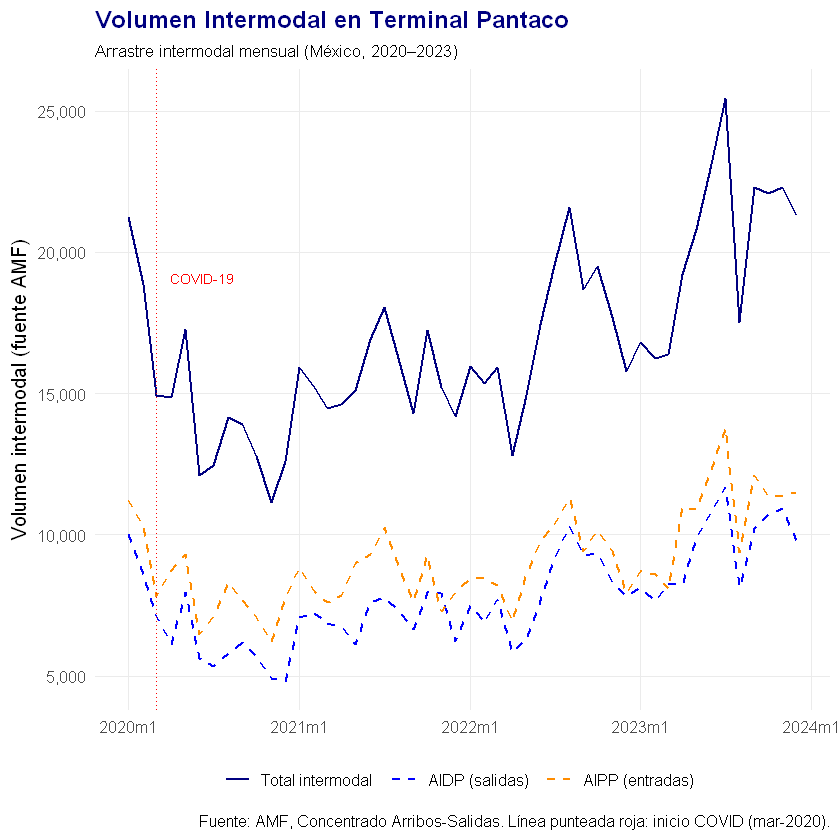

In [18]:
# Figura A: Volumen intermodal en Terminal Pantaco (AIDP, AIPP, Total)
covid_date <- as.Date("2020-03-01")

pantaco_long <- pantaco %>%
  select(fecha, aidp, aipp, intermodal_total) %>%
  pivot_longer(
    cols      = c(intermodal_total, aidp, aipp),
    names_to  = "serie",
    values_to = "valor"
  ) %>%
  mutate(
    serie = recode(serie,
      intermodal_total = "Total intermodal",
      aidp             = "AIDP (salidas)",
      aipp             = "AIPP (entradas)"
    ),
    serie = factor(serie, levels = c("Total intermodal", "AIDP (salidas)", "AIPP (entradas)"))
  )

ggplot(pantaco_long, aes(x = fecha, y = valor, color = serie, linetype = serie)) +

  geom_line(linewidth = 0.8) +

  geom_vline(
    xintercept = covid_date,
    linetype = "dotted", color = "red", linewidth = 0.4
  ) +

  annotate(
    "text",
    x     = covid_date + 30,
    y     = max(pantaco$intermodal_total) * 0.75,
    label = "COVID-19",
    color = "red", size = 3, hjust = 0
  ) +

  scale_color_manual(values = c(
    "Total intermodal" = "navy",
    "AIDP (salidas)"   = "blue",
    "AIPP (entradas)"  = "darkorange"
  )) +

  scale_linetype_manual(values = c(
    "Total intermodal" = "solid",
    "AIDP (salidas)"   = "dashed",
    "AIPP (entradas)"  = "dashed"
  )) +

  scale_x_date(date_breaks = "1 year", date_labels = "%Ym1") +

  scale_y_continuous(labels = scales::comma) +

  labs(
    title    = "Volumen Intermodal en Terminal Pantaco",
    subtitle = "Arrastre intermodal mensual (México, 2020\u20132023)",
    y        = "Volumen intermodal (fuente AMF)",
    x        = NULL,
    color    = NULL,
    linetype = NULL,
    caption  = "Fuente: AMF, Concentrado Arribos-Salidas. L\u00ednea punteada roja: inicio COVID (mar-2020)."
  ) +

  theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(color = "navy", face = "bold"),
    plot.subtitle = element_text(size = 10),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )


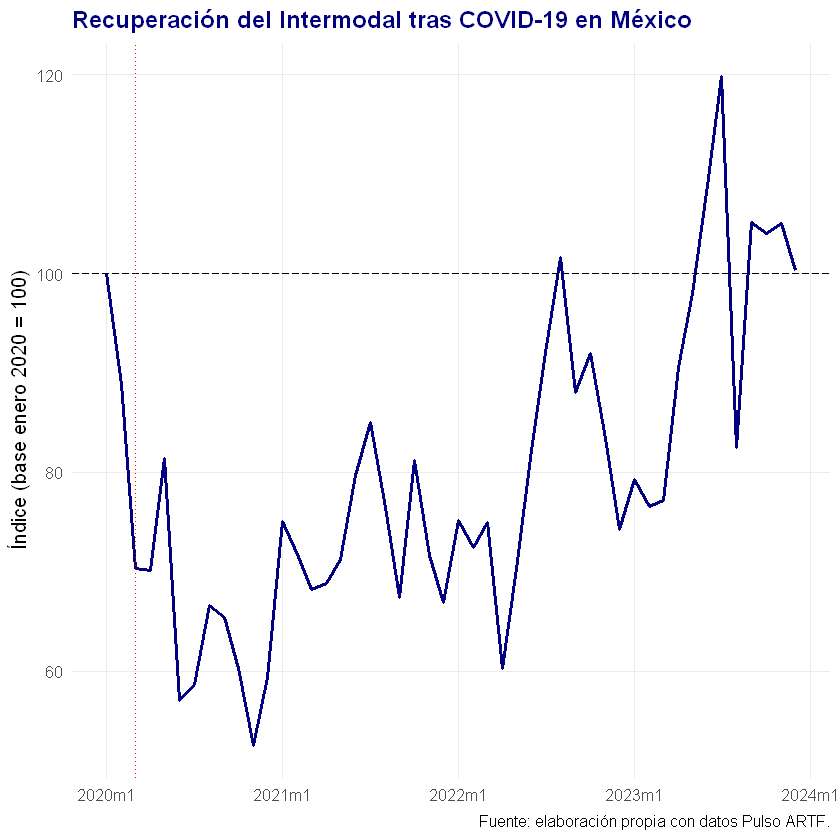

In [19]:
ggplot(pantaco, aes(x = fecha, y = indice)) +
  
  geom_line(color = "navy", linewidth = 1) +
  
  # línea horizontal base
  geom_hline(yintercept = 100, linetype = "longdash", color = "black", linewidth = 0.4) +
  
  # línea vertical COVID (marzo 2020)
  geom_vline(
    xintercept = as.Date("2020-03-01"),
    linetype = "dotted",
    color = "red",
    linewidth = 0.4
  ) +
  
  scale_x_date(date_breaks = "1 year", date_labels = "%Ym1") +
  
  labs(
    title = "Recuperación del Intermodal tras COVID-19 en México",
    y = "Índice (base enero 2020 = 100)",
    x = NULL,
    caption = "Fuente: elaboración propia con datos Pulso ARTF."
  ) +
  
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(color = "navy", face = "bold"),
    panel.grid.minor = element_blank()
  )